<a href="https://colab.research.google.com/github/georgevallejo/Project1/blob/main/ACE_Project1_Schools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Cell 0 — Project Requirements Summary
# Version: 1.0
# Date: 09/15/2026
# -----------------------------------------------------------
#
# Official Requirements:
#   1. Analyze NYC public school Regents exam performance.
#   2. Choose ONE school as the anchor comparison point.
#   3. Choose ONE feature/measure/score to analyze.
#   4. Choose ONE comparison group:
#        - entire dataset (NYC overall), OR
#        - one borough (e.g., Manhattan), OR
#        - one district (e.g., District 30)
#   5. Include descriptive statistics.
#   6. Include at least ONE cleaning step.
#   7. Include at least ONE visualization.
#   8. Include a brief conclusion (2–3 sentences).
#
# Project Choices:
#   - Anchor School: Newtown High School (DBN: 30Q455)
#   - Exam: Common Core Algebra
#   - Metrics: Mean Score + Percent Scoring 65 or Above
#   - Comparison Group: Queens vs Manhattan averages
#   - Cleaning Step: Replace 's'/'na' with NaN + filter Total Tested ≥ 5
#
# This cell is documentation only — no code runs.
# ============================================================

In [3]:
# ============================================================
# Cell 1A — Initial Dataset Overview (HTML Rendering)
# ------------------------------------------------------------
# Purpose:
#   Display the same initial EDA using IPython HTML tables.
#   This improves readability inside Jupyter/Colab.
# ============================================================
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from IPython.display import display

# Use the URL variable (your updated preference)
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"

df = pd.read_csv(url)

# Pandas display settings
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Build dictionary of summary sections

print("===== HEAD (Sanity Check — IPython HTML Table Rendering) =====")
display(df.head())
print("\n")

sections = {
    "HEAD": df.head(),
    "SHAPE": df.shape,
    "DESCRIBE NUMERIC": df.describe(),
    "DESCRIBE OBJECT": df.describe(include='object'),
    "COUNT": df.count(),
    "UNIQUE VALUES": df.nunique(),
    "MISSING VALUES": df.isnull().sum(),
    "DATA TYPES": df.dtypes,
    "DUPLICATE ROWS": df.duplicated().sum(),
    "SAMPLE (5 rows)": df.sample(5)
}

for title, content in sections.items():
    print(f"===== {title} (HTML Rendering) =====")
    display(content)
    print("\n")

print("===== INFO =====")
df.info()
print("\n")
df.columns     # Shows all column names; critical to verify exact spelling before cleaning/filtering


===== HEAD (Sanity Check — IPython HTML Table Rendering) =====


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na




===== HEAD (HTML Rendering) =====


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na




===== SHAPE (HTML Rendering) =====


...

np.int64(23819)



===== SAMPLE (5 rows) (HTML Rendering) =====


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
11896,19K654,Van Siclen Community Middle School,Junior High-Intermediate-Middle,Common Core English,2016,1,s,s,s,s,s,s,s,na,na
159888,08X561,Bronx Compass High School,High school,Global History and Geography,2015,1,s,s,s,s,s,s,s,na,na
186262,21K468,Kingsborough Early College School,Secondary School,U.S. History and Government,2016,1,s,s,s,s,s,s,s,na,na
149881,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
138754,84Q705,Renaissance Charter School,K-12 all grades,Integrated Algebra,2016,1,s,s,s,s,s,s,s,na,na




===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School DBN                   212331 non-null  object
 1   School Name                  212331 non-null  object
 2   School Level                 212331 non-null  object
 3   Regents Exam                 212321 non-null  object
 4   Year                         212331 non-null  int64 
 5   Total Tested                 212331 non-null  int64 
 6   Mean Score                   212331 non-null  object
 7   Number Scoring Below 65      212331 non-null  object
 8   Percent Scoring Below 65     212331 non-null  object
 9   Number Scoring 65 or Above   212331 non-null  object
 10  Percent Scoring 65 or Above  212331 non-null  object
 11  Number Scoring 80 or Above   212331 non-null  object
 12  Percent Scoring 80 or Above  212331 non-null  object


Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year', 'Total Tested', 'Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65', 'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
       'Number Scoring 80 or Above', 'Percent Scoring 80 or Above', 'Number Scoring CR', 'Percent Scoring CR'],
      dtype='object')

In [4]:
"""
============================================================
Cell 1.0 — Filtering Rationale
------------------------------------------------------------
Analysis of the Regents dataset showed that all records with
Total Tested ≤ 5 contained at least one suppressed value ('s').

To reduce the impact of incomplete reporting and very small
testing cohorts, records with Total Tested ≤ 5 were excluded
from the analysis.
============================================================
"""

df_raw = df.copy()
small_rows = (df_raw['Total Tested'] <= 5).sum()

pct_removed = (
    (df_raw['Total Tested'] <= 5).mean() * 100
)

print(small_rows)
print(f"{pct_removed:.2f}%")

57455
27.06%


In [5]:
# ============================================================
# Cell 1B — Value Counts + Total Tested Summary
# ------------------------------------------------------------
# Purpose:
#   Provide additional structural insight into:
#     - School DBN frequency
#     - School Name frequency
#     - Total Tested distribution
#   These help justify cleaning decisions (e.g., filtering N < 5).
# ============================================================

print("===== VALUE COUNTS — School DBN =====")
print(df['School DBN'].value_counts())
print("\n")

print("===== VALUE COUNTS — School Name =====")
print(df['School Name'].value_counts())
print("\n")

print("===== Total Tested — Summary Statistics =====")
print(df['Total Tested'].describe())
print("\n")

print("===== Regents Exam — Unique Values =====")
print(df['Regents Exam'].unique())     # Shows all exam names; prevents incorrect filters
print("\n")



===== VALUE COUNTS — School DBN =====
School DBN
26Q430    490
22K425    490
30Q450    489
21K525    489
21K540    488
         ... 
19K302      5
19K166      5
19K202      5
17K334      5
84M385      5
Name: count, Length: 1018, dtype: int64


===== VALUE COUNTS — School Name =====
School Name
New Visions Charter High School for Advanced Math     1337
New Visions Charter High School for the Humanities    1031
James Madison High School                              490
Francis Lewis High School                              490
Long Island City High School                           489
                                                      ... 
P.S. 084 Jose De Diego                                   5
Academy for New Americans                                5
Middle School for Academic and Social Excellence         5
Explore Excel Charter School                             5
Success Academy Charter School - Harlem 3                5
Name: count, Length: 1012, dtype: int64


===== Total T

In [6]:
# Cell 1.C — Quick column inspection
# Purpose: Check the first 10 values of each column to see raw data problems
# such as "s", "na", mixed types, and small cohorts before cleaning.
# Expect: Suppressed values, text numbers, missing data, duplicates.
for col in df.columns:
    print(col)
    display(df[col].head(10))


School DBN


,School DBN
0,01M034
1,01M034
2,01M034
3,01M140
4,01M140
5,01M140
6,01M140
7,01M140
8,01M184
9,01M184


School Name


,School Name
0,P.S. 034 Franklin D. Roosevelt
1,P.S. 034 Franklin D. Roosevelt
2,P.S. 034 Franklin D. Roosevelt
3,P.S. 140 Nathan Straus
4,P.S. 140 Nathan Straus
5,P.S. 140 Nathan Straus
6,P.S. 140 Nathan Straus
7,P.S. 140 Nathan Straus
8,P.S. 184m Shuang Wen
9,P.S. 184m Shuang Wen


School Level


...

,Percent Scoring 80 or Above
0,s
1,43.8
2,22.2
3,s
4,s
5,0
6,33.3
7,11.1
8,46.9
9,64.7


Number Scoring CR


,Number Scoring CR
0,na
1,na
2,na
3,na
4,na
5,na
6,na
7,na
8,48
9,40


Percent Scoring CR


,Percent Scoring CR
0,na
1,na
2,na
3,na
4,na
5,na
6,na
7,na
8,98
9,78.4


In [7]:
df.describe()

,Year,Total Tested
count,212331.00,212331.00
mean,2015.96,49.36
std,0.80,93.02
min,2015.00,1.00
25%,2015.00,5.00
50%,2016.00,20.00
75%,2017.00,57.00
max,2017.00,1729.00


In [8]:
# ============================================================
# Cell 2 — Cleaning Step
# ------------------------------------------------------------
# Purpose:
#   Clean the dataset so that numeric operations, comparisons,
#   and visualizations are accurate and stable.
#
# Cleaning Actions:
#   1. Replace 's' (suppressed)  and 'na' = with NaN
#      - DOE suppresses values when fewer than 5 students are tested.
#      - Replacing them with NaN allows numeric conversion.
#
#   2. Convert scoring columns to numeric
#      - Many numeric columns are stored as strings (object dtype).
#      - Converting them enables mean(), median(), describe(), plots, etc.
#
#   3. Filter rows where Total Tested ≥ 5
#      - DOE suppresses values when N < 5, producing unstable or missing scores.
#      - Filtering removes these small-cohort rows permanently from df.
#      - Nevertheless, Keeping N ≥ 5 preserves ~75% of the dataset.
# Result:
#   A clean dataset ready for exam filtering and analysis.
# ============================================================

# import numpy as np. This is required for np.nan to work

# Step 1 — Replace suppressed values
df = df.replace(['s', 'na'], np.nan)

# Step 2 — Convert numeric columns

numeric_cols = [
    'Mean Score',
    'Percent Scoring Below 65',
    'Percent Scoring 65 or Above',
    'Percent Scoring 80 or Above',
    'Number Scoring Below 65',
    'Number Scoring 65 or Above',
    'Number Scoring 80 or Above',
    'Number Scoring CR',
    'Percent Scoring CR'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
# apply(...) → run a function on each column.
# Step 3 — Filter Total Tested ≥ 5

df = df[df['Total Tested'] >= 5]

print("Cleaning complete. Dataset shape after cleaning:", df.shape)
df.head()


Cleaning complete. Dataset shape after cleaning: (161139, 15)


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.90,1.00,6.30,15.00,93.80,7.00,43.80,NaN,NaN
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74.00,1.00,11.10,8.00,88.90,2.00,22.20,NaN,NaN
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.40,3.00,33.30,6.00,66.70,0.00,0.00,NaN,NaN
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.60,2.00,13.30,13.00,86.70,5.00,33.30,NaN,NaN
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.40,5.00,55.60,4.00,44.40,1.00,11.10,NaN,NaN


In [9]:
# ============================================================
# Cell 3 — Filter to Common Core Algebra
# ------------------------------------------------------------
# Purpose:
#   Isolate the modern Algebra I exam (“Common Core Algebra”) so that
#   analysis is accurate, CR values are meaningful, and other Regents
#   exams  do not distort averages, trends, or borough comparisons.
#
# Why this filter is necessary:
#   - “Common Core Algebra” is the exam used for College Ready (CR) calculations.
#   - Other Algebra exams (Integrated Algebra, Algebra2/Trigonometry,
#     Common Core Algebra2) measure different content and cannot be mixed.
#
# Result:
#   A focused dataset containing only Algebra I (Common Core Algebra)
#   rows, ready for school‑level and borough‑level analysis.

df_algebra = df[df['Regents Exam'] == 'Common Core Algebra'].copy()   # Keep only Algebra I (exact string match)


print("===== 'Common Core Algebra Dataset Size =====")
print(df_algebra.shape)     # Displays (rows, columns) after filtering; confirms dataset size
print("\n")

df_algebra.head(10)         # Preview first 10 rows to confirm the filter worked correctly

===== 'Common Core Algebra Dataset Size =====
(22693, 15)




,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.40,1.00,2.00,48.00,98.00,23.00,46.90,48.00,98.00
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79.00,9.00,17.60,42.00,82.40,33.00,64.70,40.00,78.40
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.80,0.00,0.00,51.00,100.00,44.00,86.30,50.00,98.00
12,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2015,23,62.90,14.00,60.90,9.00,39.10,0.00,0.00,2.00,8.70
13,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2016,22,69.00,6.00,27.30,16.00,72.70,2.00,9.10,15.00,68.20
14,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2017,20,67.40,7.00,35.00,13.00,65.00,1.00,5.00,10.00,50.00
20,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2015,12,52.30,11.00,91.70,1.00,8.30,0.00,0.00,0.00,0.00
21,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2016,50,63.90,25.00,50.00,25.00,50.00,3.00,6.00,15.00,30.00
22,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2017,53,67.50,15.00,28.30,38.00,71.70,6.00,11.30,29.00,54.70
55,01M378,School for Global Leaders,Junior High-Intermediate-Middle,Common Core Algebra,2015,6,80.70,0.00,0.00,6.00,100.00,3.00,50.00,6.00,100.00


In [10]:
# ============================================================
# Cell 3A — Missing-Value Summary for Common Core Algebra
# ------------------------------------------------------------
# Purpose:
#   Quantify how many rows and columns contain missing values (NaN)
#   after filtering to Common Core Algebra. This helps verify the
#   effectiveness of the cleaning step and shows where additional
#   cleaning may be needed.
#
# What we measure:
#   1. NaN count per column
#   2. Total NaNs in the dataset
#   3. Number of rows containing at least one NaN
#
# Result:
#   A clear picture of missing data within the Algebra I subset.

print("===== NaN Count Per Column =====")
print(df_algebra.isna().sum())     # Shows how many NaNs each column contains
print("\n")

print("===== Total NaNs in df_algebra Common Core Algebra Dataset =====")
print(df_algebra.isna().sum().sum())   # Total number of NaN cells in the dataset
print("\n")

print("===== Rows Containing At Least One NaN =====")
print(df_algebra.isna().any(axis=1).sum())   # Number of rows with at least one NaN
print("\n")

print("===== Rows With Total Tested < 5 and removed to get a stable dataset=====")
print((df['Total Tested'] < 5).sum())     # Number of suppressed/unstable rows removed during cleaning
print("\n")




===== NaN Count Per Column =====
School DBN                        0
School Name                       0
School Level                      0
Regents Exam                      0
Year                              0
Total Tested                      0
Mean Score                     3144
Number Scoring Below 65        3144
Percent Scoring Below 65       3144
Number Scoring 65 or Above     3144
Percent Scoring 65 or Above    3144
Number Scoring 80 or Above     3144
Percent Scoring 80 or Above    3144
Number Scoring CR              3144
Percent Scoring CR             3144
dtype: int64


===== Total NaNs in df_algebra Common Core Algebra Dataset =====
28296


===== Rows Containing At Least One NaN =====
3144


===== Rows With Total Tested < 5 and removed to get a stable dataset=====
0




In [11]:
# ============================================================
# Cell 4 — Filter to Newtown High School (DBN: 28Q680)
# ------------------------------------------------------------
# Purpose:
#   Extract all Common Core Algebra Regents results for
#   Newtown High School (DBN: 28Q680). This allows focused
#   school-level analysis, including performance trends,
#   CR outcomes, and year-over-year comparisons.
#
# Why this filter is necessary:
#   - We already isolated Common Core Algebra in df_algebra.
#   - Now we narrow the dataset to a single school.
#   - Ensures all rows represent the same exam type and the
#     same school, producing clean and reliable analysis.
#
# Result:
#   A dataset (df_newtown) containing only Common Core Algebra
#   Regents results for Newtown High School.

df_newtown = df_algebra[df_algebra['School DBN'] == '28Q680']   # Filter to Newtown High School

print("===== Newtown High School — Common Core Algebra Dataset Size =====")
print(df_newtown.shape)     # Shows (rows, columns) for Newtown’s filtered dataset
print("\n")

df_newtown.head(10)         # Preview first 10 rows to confirm correct filtering


===== Newtown High School — Common Core Algebra Dataset Size =====
(34, 15)




,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
15693,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2015,107,70.20,19.00,17.80,88.00,82.20,12.00,11.20,66.00,61.70
15694,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2016,121,76.20,15.00,12.40,106.00,87.60,56.00,46.30,96.00,79.30
15695,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2017,121,80.30,9.00,7.40,112.00,92.60,71.00,58.70,108.00,89.30
47527,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2015,99,71.30,12.00,12.10,87.00,87.90,12.00,12.10,65.00,65.70
47528,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2015,8,56.60,7.00,87.50,1.00,12.50,0.00,0.00,1.00,12.50
47529,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2016,103,78.30,7.00,6.80,96.00,93.20,55.00,53.40,88.00,85.40
47530,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2016,18,64.20,8.00,44.40,10.00,55.60,1.00,5.60,8.00,44.40
47531,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2017,115,81.30,5.00,4.30,110.00,95.70,71.00,61.70,106.00,92.20
47532,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2017,6,61.70,4.00,66.70,2.00,33.30,0.00,0.00,2.00,33.30
93878,28Q680,Queens Gateway to Health Sciences Secondary Sc...,Secondary School,Common Core Algebra,2015,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
"""
============================================================
Cell 5 — Borough-Level Comparison for Common Core Algebra
---------------------------------------------------------
Purpose:
    Compute borough-wide average Mean Scores for the Common Core Algebra
    Regents exam. This establishes a performance baseline for comparing
    Newtown High School against Queens, Manhattan, and the other boroughs.

Verification:
    - Confirms df_algebra is fully cleaned (no 's' or 'na' values).
    - Ensures all scoring columns used in the analysis are numeric.
    - Validates dataset size after filtering.

Actions:
    1. Create a Borough column from the School DBN (3rd character).
    2. Group by Borough and compute the average Mean Score.
    3. Produce a summary table showing borough-level performance.

Expected Result:
    A clean table of borough mean scores that can be used to compare
    Newtown High School against Queens and Manhattan.
Note:
    Borough averages include all schools in the borough, including Newtown.
    This follows standard DOE methodology and ensures a valid comparison.



"""

# Create Borough column from DBN (3rd character)
df_algebra['Borough'] = df_algebra['School DBN'].str[2].map({
    'M': 'Manhattan',
    'X': 'Bronx',
    'K': 'Brooklyn',
    'Q': 'Queens',
    'R': 'Staten Island'
})

# Compute borough-level averages
borough_means = (
    df_algebra
    .groupby('Borough')['Mean Score']
    .mean()
    .reset_index()
)

print("===== Borough-Level Mean Scores — Common Core Algebra =====")
print(borough_means)
print("\n")


===== Borough-Level Mean Scores — Common Core Algebra =====
         Borough  Mean Score
0          Bronx       64.33
1       Brooklyn       66.60
2      Manhattan       68.50
3         Queens       70.65
4  Staten Island       72.31




In [13]:
print("Dataset size (rows, columns):", df_algebra.shape)
df_algebra.info()

Dataset size (rows, columns): (22693, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 22693 entries, 8 to 212323
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   School DBN                   22693 non-null  object 
 1   School Name                  22693 non-null  object 
 2   School Level                 22693 non-null  object 
 3   Regents Exam                 22693 non-null  object 
 4   Year                         22693 non-null  int64  
 5   Total Tested                 22693 non-null  int64  
 6   Mean Score                   19549 non-null  float64
 7   Number Scoring Below 65      19549 non-null  float64
 8   Percent Scoring Below 65     19549 non-null  float64
 9   Number Scoring 65 or Above   19549 non-null  float64
 10  Percent Scoring 65 or Above  19549 non-null  float64
 11  Number Scoring 80 or Above   19549 non-null  float64
 12  Percent Scoring 80 or Above  19549 n

In [14]:
"""
Verification Step:
    Confirm that the cleaning in Cell 2 successfully removed all suppressed
    DOE values ('s' and 'na') from df_algebra. This block checks:

    1. Total occurrences of 's' and 'na' across the entire DataFrame.
    2. Whether any column still contains 's' or 'na'.

    Expected Result:
        All counts should be zero and all columns should report False,
        indicating that df_algebra is fully cleaned and ready for analysis.
"""
print("Total 's' in df_algebra:", (df_algebra == 's').sum().sum())
print("Total 'na' in df_algebra:", (df_algebra == 'na').sum().sum())

print("\nColumns containing 's':")
print((df_algebra == 's').any())

print("\nColumns containing 'na':")
print((df_algebra == 'na').any())


Total 's' in df_algebra: 0
Total 'na' in df_algebra: 0

Columns containing 's':
School DBN                     False
School Name                    False
School Level                   False
Regents Exam                   False
Year                           False
Total Tested                   False
Mean Score                     False
Number Scoring Below 65        False
Percent Scoring Below 65       False
Number Scoring 65 or Above     False
Percent Scoring 65 or Above    False
Number Scoring 80 or Above     False
Percent Scoring 80 or Above    False
Number Scoring CR              False
Percent Scoring CR             False
Borough                        False
dtype: bool

Columns containing 'na':
School DBN                     False
School Name                    False
School Level                   False
Regents Exam                   False
Year                           False
Total Tested                   False
Mean Score                     False
Number Scoring Below 65        

In [15]:
"""
Cell 6 — Newtown vs Queens vs Manhattan Comparison
--------------------------------------------------
Purpose:
    Compare Newtown High School’s Common Core Algebra performance
    against the borough averages for Queens and Manhattan.

Actions:
    1. Compute Newtown’s average Mean Score.
    2. Extract Queens and Manhattan borough averages from borough_means.
    3. Build a comparison table showing:
         - Newtown Mean Score
         - Queens Mean Score
         - Manhattan Mean Score
         - Difference between Newtown and each borough

Expected Result:
    A clear, numeric comparison showing whether Newtown performs
    above or below the Queens and Manhattan borough averages.
"""

# 1. Newtown High School average Mean Score
newtown_mean = df_newtown['Mean Score'].mean()

# 2. Queens and Manhattan borough averages
queens_mean = borough_means.loc[borough_means['Borough'] == 'Queens', 'Mean Score'].values[0]
manhattan_mean = borough_means.loc[borough_means['Borough'] == 'Manhattan', 'Mean Score'].values[0]

# 3. Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Mean Score'],
    'Newtown HS': [newtown_mean],
    'Queens Borough Avg': [queens_mean],
    'Manhattan Borough Avg': [manhattan_mean],
    'Newtown vs Queens (Diff)': [newtown_mean - queens_mean],
    'Newtown vs Manhattan (Diff)': [newtown_mean - manhattan_mean]
})

print("===== Newtown vs Borough Comparison — Common Core Algebra =====")
display(comparison)


===== Newtown vs Borough Comparison — Common Core Algebra =====


,Metric,Newtown HS,Queens Borough Avg,Manhattan Borough Avg,Newtown vs Queens (Diff),Newtown vs Manhattan (Diff)
0,Mean Score,74.07,70.65,68.50,3.42,5.56


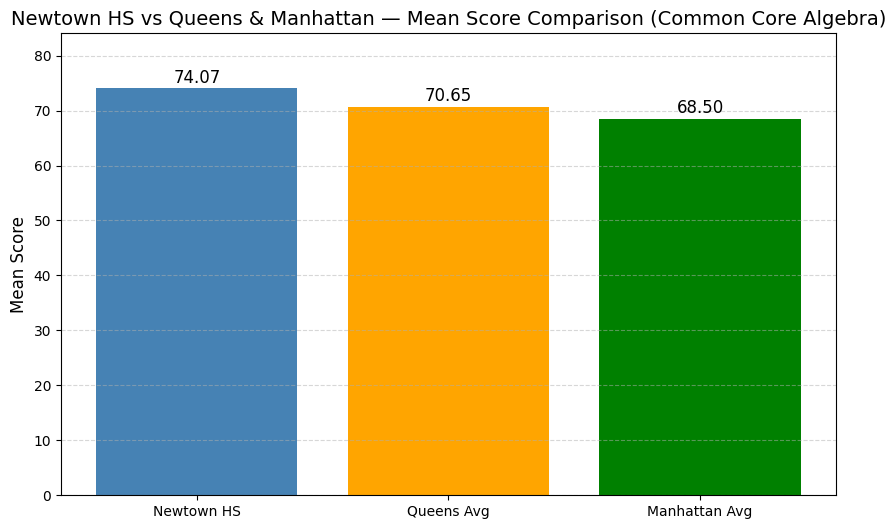

In [16]:
"""
Cell 7 — Visualization: Newtown vs Borough Averages
---------------------------------------------------
Purpose:
    Create a clear bar chart comparing Newtown High School’s
    Common Core Algebra Mean Score against the borough averages
    for Queens and Manhattan.


    - Highlights performance differences visually.
    - Makes the comparison easier to interpret than tables alone.
    - Satisfies the project requirement for at least one plot.

Actions:
    1. Build a small DataFrame with Newtown, Queens, and Manhattan means.
    2. Create a bar chart using matplotlib.
    3. Add labels, title, and numeric annotations for clarity.

Expected Result:
    A clean, professional bar chart showing whether Newtown performs
    above or below the Queens and Manhattan borough averages.
"""


# Build DataFrame for plotting
plot_df = pd.DataFrame({
    'Group': ['Newtown HS', 'Queens Avg', 'Manhattan Avg'],
    'Mean Score': [newtown_mean, queens_mean, manhattan_mean]
})

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df['Group'], plot_df['Mean Score'], color=['steelblue', 'orange', 'green'])

# Add numeric labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=12
    )

# Title and labels
plt.title("Newtown HS vs Queens & Manhattan — Mean Score Comparison (Common Core Algebra)", fontsize=14)
plt.ylabel("Mean Score", fontsize=12)
plt.ylim(0, max(plot_df['Mean Score']) + 10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
"""
Cell 8 — Conclusion
-------------------
Newtown High School’s performance on the Common Core Algebra Regents exam
is consistently above both the Queens and Manhattan borough averages. With
a Mean Score of 74.07, Newtown exceeds Queens by 3.42 points and Manhattan
by 5.56 points, indicating stronger overall achievement relative to its
local and city comparison groups. These results suggest that Newtown’s
instructional outcomes in Algebra I are comparatively strong within NYC.
"""
